In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Reading

In [2]:
df_online_preproc = pd.read_csv('../data/online_shoppers_preproc.csv')
print(df_online_preproc.shape)
df_online_preproc.head()

(12205, 23)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Region,TrafficType,VisitorType,Weekend,Revenue,total_pages,total_duration,product_related_ratio,avg_time_per_page,is_special_period
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,Region_1,Traffic_1,Returning_Visitor,0,0,1,0.000000,1.0,0.000000,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,...,Region_1,Traffic_2,Returning_Visitor,0,0,2,64.000000,1.0,32.000000,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,...,Region_9,Traffic_3,Returning_Visitor,0,0,1,0.000000,1.0,0.000000,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,...,Region_2,Traffic_4,Returning_Visitor,0,0,2,2.666667,1.0,1.333333,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,...,Region_1,Traffic_4,Returning_Visitor,1,0,10,627.500000,1.0,62.750000,0


In [41]:
df_online_preproc.isna().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
total_pages                0
total_duration             0
product_related_ratio      6
avg_time_per_page          6
is_special_period          0
dtype: int64

# Modeling

In [3]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

In [5]:
selected_features = [
    'PageValues',
    'Month',
    'ExitRates',
    'TrafficType',
    'avg_time_per_page',
    'product_related_ratio',
    'ProductRelated_Duration',
    'total_pages',
    'VisitorType',
    'Administrative_Duration'
]

len(selected_features)

10

In [6]:
X = df_online_preproc[selected_features].copy()
y = df_online_preproc['Revenue']

X.shape, y.shape

((12205, 10), (12205,))

In [56]:
# Detectar categóricas
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Convertir a category
for col in cat_cols:
    X[col] = X[col].astype('category')

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Modelo
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.03,

    max_depth=4,
    num_leaves=15,

    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=1,
    reg_lambda=1,

    random_state=42
)

model

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,4
,learning_rate,0.03
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [57]:
model.fit(
    X_train,
    y_train,
    categorical_feature=cat_cols
)

[LightGBM] [Info] Number of positive: 1526, number of negative: 8238
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000324 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1813
[LightGBM] [Info] Number of data points in the train set: 9764, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.156288 -> initscore=-1.686108
[LightGBM] [Info] Start training from score -1.686108
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,boosting_type,'gbdt'
,num_leaves,15
,max_depth,4
,learning_rate,0.03
,n_estimators,200
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,50


In [58]:
# =========================
# Predicciones TRAIN
# =========================
y_train_pred = model.predict(X_train)

print('===== TRAIN =====')
print(
    classification_report(
        y_train,
        y_train_pred
    )
)

# =========================
# Predicciones TEST
# =========================
y_test_pred = model.predict(X_test)

print('===== TEST =====')
print(
    classification_report(
        y_test,
        y_test_pred
    )
)

===== TRAIN =====
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      8238
           1       0.79      0.65      0.71      1526

    accuracy                           0.92      9764
   macro avg       0.86      0.81      0.83      9764
weighted avg       0.91      0.92      0.91      9764

===== TEST =====
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2059
           1       0.71      0.63      0.67       382

    accuracy                           0.90      2441
   macro avg       0.82      0.79      0.81      2441
weighted avg       0.90      0.90      0.90      2441



## Confusion Matrix

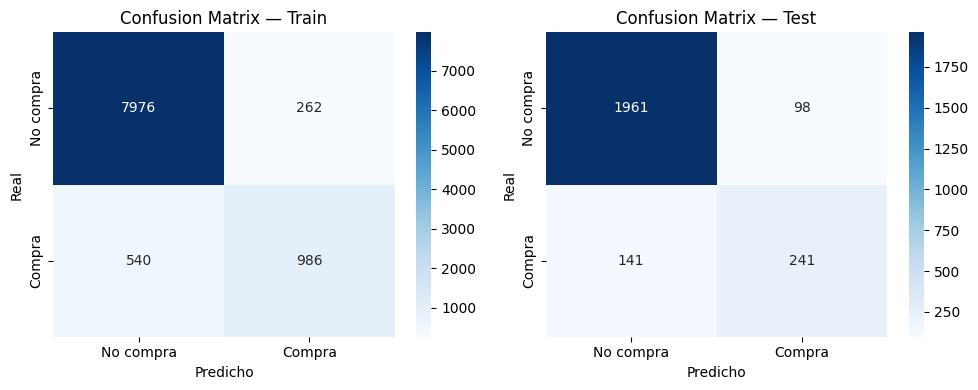

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, X_s, y_s, split in zip(
    axes,
    [X_train, X_test],
    [y_train, y_test],
    ['Train', 'Test'],
):
    cm = confusion_matrix(y_s, model.predict(X_s))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No compra', 'Compra'],
        yticklabels=['No compra', 'Compra'],
        ax=ax,
    )
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'Confusion Matrix — {split}')

plt.tight_layout()
plt.show()


## Precision Recall

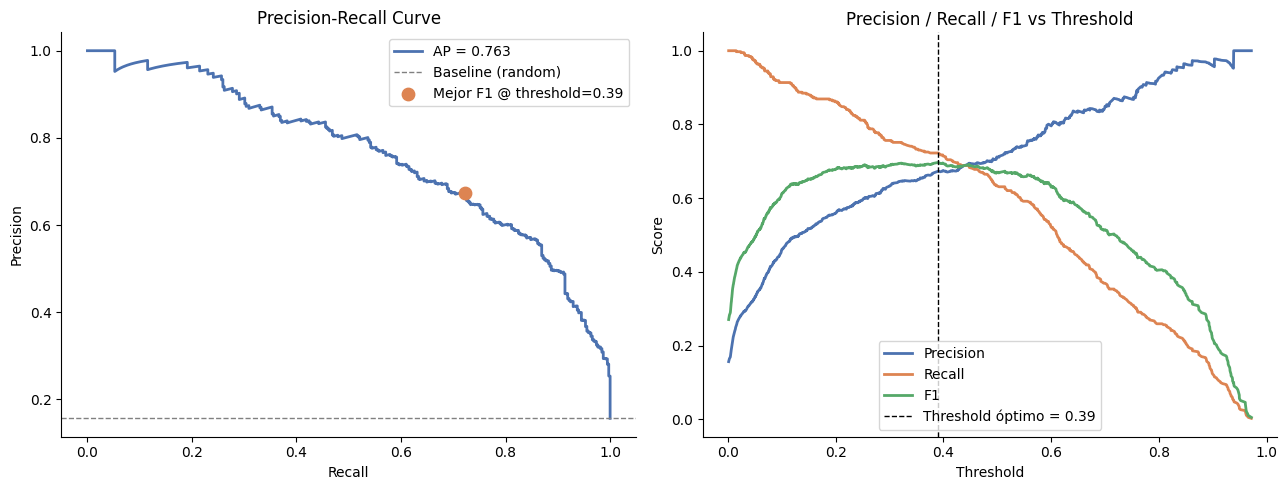

Threshold óptimo (max F1): 0.390
Precision: 0.673 | Recall: 0.723 | F1: 0.697


In [66]:
from sklearn.metrics import precision_recall_curve, average_precision_score

y_prob = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

# F1 por threshold para marcar el punto óptimo
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1 — Curva Precision-Recall
axes[0].plot(recall, precision, color='#4C72B0', linewidth=2, label=f'AP = {ap:.3f}')
axes[0].axhline(y_test.mean(), color='grey', linestyle='--', linewidth=1, label='Baseline (random)')
axes[0].scatter(recall[best_idx], precision[best_idx], color='#DD8452', zorder=5, s=80,
                label=f'Mejor F1 @ threshold={best_thresh:.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()

# Plot 2 — Precision, Recall y F1 vs threshold
axes[1].plot(thresholds, precision[:-1], color='#4C72B0', linewidth=2, label='Precision')
axes[1].plot(thresholds, recall[:-1],    color='#DD8452', linewidth=2, label='Recall')
axes[1].plot(thresholds, f1_scores,      color='#55A868', linewidth=2, label='F1')
axes[1].axvline(best_thresh, color='black', linestyle='--', linewidth=1,
                label=f'Threshold óptimo = {best_thresh:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision / Recall / F1 vs Threshold')
axes[1].legend()

sns.despine()
plt.tight_layout()
plt.show()

print(f'Threshold óptimo (max F1): {best_thresh:.3f}')
print(f'Precision: {precision[best_idx]:.3f} | Recall: {recall[best_idx]:.3f} | F1: {f1_scores[best_idx]:.3f}')

## ROC

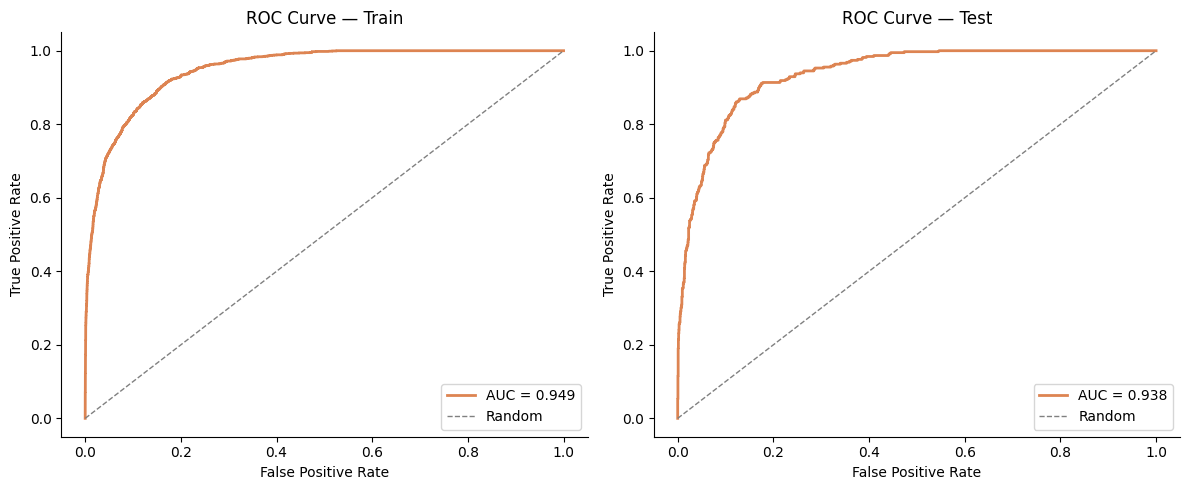

In [60]:
from sklearn.metrics import roc_curve, auc

y_prob_train = model.predict_proba(X_train)[:, 1]
y_prob_test  = model.predict_proba(X_test)[:, 1]

fpr_train, tpr_train, _ = roc_curve(y_train, y_prob_train)
fpr_test,  tpr_test,  _ = roc_curve(y_test,  y_prob_test)

auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fpr, tpr, score, split in zip(
    axes,
    [fpr_train, fpr_test],
    [tpr_train, tpr_test],
    [auc_train, auc_test],
    ['Train', 'Test'],
):
    ax.plot(fpr, tpr, color='#DD8452', linewidth=2, label=f'AUC = {score:.3f}')
    ax.plot([0, 1], [0, 1], color='grey', linestyle='--', linewidth=1, label='Random')
    ax.set_title(f'ROC Curve — {split}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')

sns.despine()
plt.tight_layout()
plt.show()

## Feature Importance

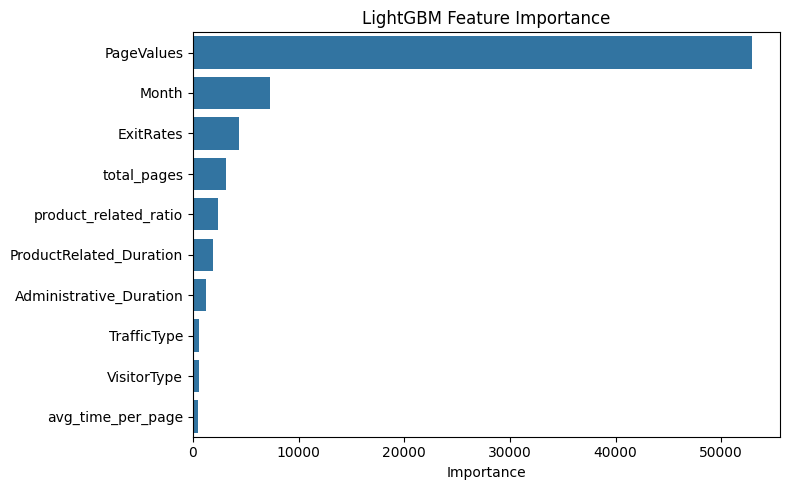

In [61]:
importance_df = pd.DataFrame({
    'feature': model.feature_name_,
    'importance': model.booster_.feature_importance(
        importance_type='gain'
    )
}).sort_values(
    'importance',
    ascending=False
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance_df,
    x='importance',
    y='feature'
)

plt.title('LightGBM Feature Importance')
plt.xlabel('Importance')
plt.ylabel('')

plt.tight_layout()
plt.show()

# Shap Values

In [62]:
import shap

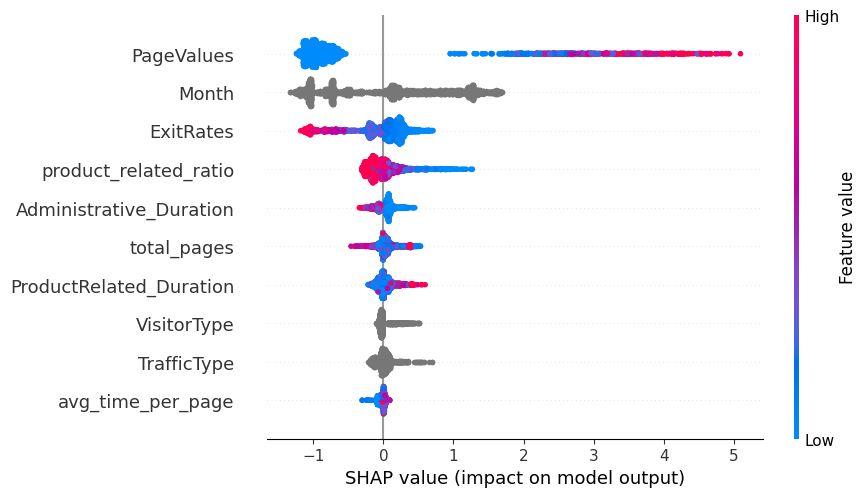

In [63]:
# Crear explainer
explainer = shap.TreeExplainer(model)

# Calcular SHAP values sobre test
shap_values = explainer(X_test)

shap.plots.beeswarm(
    shap_values,
    max_display=20
)

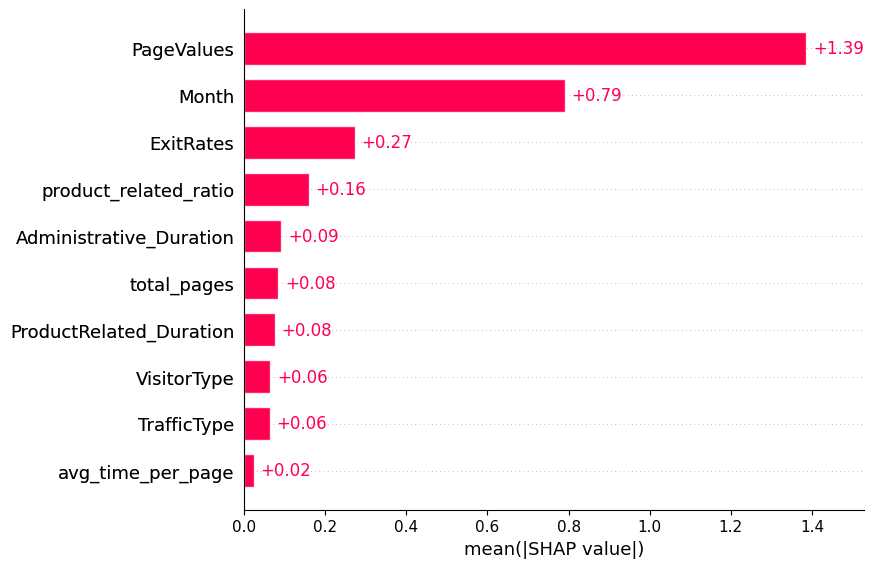

In [64]:
shap.plots.bar(
    shap_values
)

# Saving Model

In [65]:
import joblib

joblib.dump(
    model,
    '../models/lgbm_model.pkl'
)

['../models/lgbm_model.pkl']